<a href="https://colab.research.google.com/github/Kubenew/TurboQuant-v3/blob/main/TurboQuant_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TurboQuant v3 (INT4 + AWQ + Protected Channels + Low-Rank)
This notebook demonstrates a **TurboQuant-like** quantization algorithm:
- Group-wise INT4 quantization
- Activation-aware scaling (AWQ-style)
- Protected FP16 channels
- Optional low-rank correction (SVD)

Run cells top-to-bottom.

# TurboQuant v3 (INT4 + AWQ + Protected Channels + Low-Rank)
This notebook demonstrates a **TurboQuant-like** quantization algorithm:
- Group-wise INT4 quantization
- Activation-aware scaling (AWQ-style)
- Protected FP16 channels
- Optional low-rank correction (SVD)

Run cells top-to-bottom.

In [1]:
import numpy as np
print('TurboQuant v3 notebook loaded')

TurboQuant v3 notebook loaded


## INT4 pack/unpack utilities

In [2]:
import numpy as np

def pack_int4(values_int8):
    """
    Pack int4 values (-8..7) into uint8 array (2 values per byte).
    """
    v = np.asarray(values_int8, dtype=np.int8)
    assert np.all(v >= -8) and np.all(v <= 7)

    nibbles = (v & 0x0F).astype(np.uint8)

    if len(nibbles) % 2 != 0:
        nibbles = np.append(nibbles, 0)

    packed = (nibbles[0::2] | (nibbles[1::2] << 4)).astype(np.uint8)
    return packed


def unpack_int4(packed_uint8, length):
    """
    Unpack uint8 array into int4 values (-8..7).
    """
    p = np.asarray(packed_uint8, dtype=np.uint8)

    low = p & 0x0F
    high = (p >> 4) & 0x0F

    nibbles = np.empty(len(p) * 2, dtype=np.uint8)
    nibbles[0::2] = low
    nibbles[1::2] = high
    nibbles = nibbles[:length]

    out = nibbles.astype(np.int8)
    out[out >= 8] -= 16
    return out

print('INT4 pack/unpack ready')

INT4 pack/unpack ready


## Low-rank correction (SVD)

In [3]:
def lowrank_correction(R, rank):
    """
    R ≈ U @ V (stored fp16)
    """
    U, S, Vt = np.linalg.svd(R, full_matrices=False)

    U_k = U[:, :rank]
    S_k = S[:rank]
    Vt_k = Vt[:rank, :]

    # absorb S into U for efficiency
    U_corr = (U_k * S_k).astype(np.float16)
    V_corr = Vt_k.astype(np.float16)

    return U_corr, V_corr

print('Low rank correction ready')

Low rank correction ready


## TurboQuant v3 compress / decompress

In [4]:
def turboquant_v3_compress(
    W,
    group_size=64,
    outlier_keep_ratio=0.02,
    rank=8,
    activation_aware=True
):
    """
    Production-style TurboQuant-like compressor:
    - groupwise int4 quantization per row
    - activation-aware scaling (AWQ-like)
    - protect top sensitive input channels (keep fp16)
    - low rank correction (optional)
    """
    W = np.asarray(W, dtype=np.float32)
    out_dim, in_dim = W.shape

    # Simulated activation statistics (in real LLM: collected from calibration runs)
    if activation_aware:
        act_stats = np.random.lognormal(mean=0.0, sigma=0.6, size=in_dim).astype(np.float32)
        act_stats /= (np.max(act_stats) + 1e-9)
    else:
        act_stats = np.ones(in_dim, dtype=np.float32)

    # Choose protected columns (most important channels)
    col_importance = np.mean(np.abs(W), axis=0) * act_stats
    k_keep = max(1, int(in_dim * outlier_keep_ratio))

    protected_cols = np.argsort(col_importance)[-k_keep:].astype(np.int32)
    protected_fp16 = W[:, protected_cols].astype(np.float16)

    W_base = W.copy()
    W_base[:, protected_cols] = 0.0

    groups = (in_dim + group_size - 1) // group_size

    packed_rows = []
    scales = np.zeros((out_dim, groups), dtype=np.float16)

    for r in range(out_dim):
        row = W_base[r]
        row_packed_groups = []

        for g in range(groups):
            start = g * group_size
            end = min(start + group_size, in_dim)
            block = row[start:end]

            weighted = np.abs(block) * act_stats[start:end]
            max_abs = np.max(weighted) + 1e-9
            scale = (max_abs / 7.0).astype(np.float16)

            q = np.round(block / float(scale)).astype(np.int8)
            q = np.clip(q, -8, 7)

            packed = pack_int4(q)

            scales[r, g] = scale
            row_packed_groups.append((start, end, packed))

        packed_rows.append(row_packed_groups)

    # reconstruct quantized approx for residual correction
    tmp_comp = {
        "shape": (out_dim, in_dim),
        "group_size": group_size,
        "protected_cols": protected_cols,
        "protected_fp16": protected_fp16,
        "packed_rows": packed_rows,
        "scales": scales,
        "rank": 0,
        "U_corr": None,
        "V_corr": None
    }
    Wq = turboquant_v3_decompress(tmp_comp)

    # low-rank correction
    if rank > 0:
        R = (W - Wq).astype(np.float32)
        U_corr, V_corr = lowrank_correction(R, rank=rank)
    else:
        U_corr, V_corr = None, None

    return {
        "shape": (out_dim, in_dim),
        "group_size": group_size,
        "protected_cols": protected_cols,
        "protected_fp16": protected_fp16,
        "packed_rows": packed_rows,
        "scales": scales,
        "rank": rank,
        "U_corr": U_corr,
        "V_corr": V_corr
    }


def turboquant_v3_decompress(comp):
    out_dim, in_dim = comp["shape"]
    group_size = comp["group_size"]
    groups = (in_dim + group_size - 1) // group_size

    W_rec = np.zeros((out_dim, in_dim), dtype=np.float32)

    for r in range(out_dim):
        for g in range(groups):
            start, end, packed = comp["packed_rows"][r][g]
            scale = float(comp["scales"][r, g])
            length = end - start

            q = unpack_int4(packed, length)
            W_rec[r, start:end] = q.astype(np.float32) * scale

    protected_cols = comp["protected_cols"]
    W_rec[:, protected_cols] = comp["protected_fp16"].astype(np.float32)

    if comp["rank"] > 0:
        U_corr = comp["U_corr"].astype(np.float32)
        V_corr = comp["V_corr"].astype(np.float32)
        W_rec = W_rec + (U_corr @ V_corr)

    return W_rec

print('TurboQuant v3 functions ready')

TurboQuant v3 functions ready


## Metrics: size + reconstruction error

In [5]:
def turboquant_v3_size_bytes(comp):
    out_dim, in_dim = comp["shape"]
    group_size = comp["group_size"]
    groups = (in_dim + group_size - 1) // group_size

    scales_bytes = out_dim * groups * 2

    packed_bytes = 0
    for r in range(out_dim):
        for g in range(groups):
            _, _, packed = comp["packed_rows"][r][g]
            packed_bytes += len(packed)

    protected_cols = comp["protected_cols"]
    protected_bytes = out_dim * len(protected_cols) * 2
    protected_idx_bytes = len(protected_cols) * 4

    corr_bytes = 0
    if comp["rank"] > 0:
        rank = comp["rank"]
        corr_bytes = (out_dim * rank * 2) + (rank * in_dim * 2)

    return scales_bytes + packed_bytes + protected_bytes + protected_idx_bytes + corr_bytes


def error_stats(W, W_rec):
    diff = W - W_rec
    mse = float(np.mean(diff**2))
    mae = float(np.mean(np.abs(diff)))
    max_err = float(np.max(np.abs(diff)))
    return mse, mae, max_err

print('Metrics ready')

Metrics ready


## Run experiment

In [6]:
np.random.seed(42)

out_dim = 512
in_dim = 1024

# Transformer-like distribution
W = np.random.normal(0, 0.02, size=(out_dim, in_dim)).astype(np.float32)

# Inject outliers
for _ in range(800):
    r = np.random.randint(0, out_dim)
    c = np.random.randint(0, in_dim)
    W[r, c] += np.random.choice([-1, 1]) * np.random.uniform(0.2, 1.2)

original_bytes = W.nbytes

comp = turboquant_v3_compress(
    W,
    group_size=64,
    outlier_keep_ratio=0.02,
    rank=8,
    activation_aware=True
)

W_rec = turboquant_v3_decompress(comp)

compressed_bytes = turboquant_v3_size_bytes(comp)
mse, mae, max_err = error_stats(W, W_rec)

print('Matrix:', W.shape)
print('Original bytes:', original_bytes)
print('Compressed bytes:', compressed_bytes)
print('Compression ratio:', original_bytes / compressed_bytes)

print('MSE:', mse)
print('MAE:', mae)
print('Max abs error:', max_err)

print('Protected cols:', len(comp['protected_cols']))
print('Correction rank:', comp['rank'])

Matrix: (512, 1024)
Original bytes: 2097152
Compressed bytes: 323664
Compression ratio: 6.479410746947452
MSE: 0.0006936939898878336
MAE: 0.007696299813687801
Max abs error: 1.2790563106536865
Protected cols: 20
Correction rank: 8


## Compare ranks

In [7]:
ranks = [0, 4, 8, 16]
results = []

for rk in ranks:
    comp2 = turboquant_v3_compress(
        W,
        group_size=64,
        outlier_keep_ratio=0.02,
        rank=rk,
        activation_aware=True
    )
    W_rec2 = turboquant_v3_decompress(comp2)

    compressed_bytes2 = turboquant_v3_size_bytes(comp2)
    mse2, mae2, max_err2 = error_stats(W, W_rec2)

    results.append((rk, original_bytes / compressed_bytes2, mse2, mae2, max_err2))

print("Rank | Compression | MSE | MAE | MaxErr")
for rk, cr, mse2, mae2, mx in results:
    print(f"{rk:4d} | {cr:11.3f}x | {mse2:.8f} | {mae2:.8f} | {mx:.6f}")

Rank | Compression | MSE | MAE | MaxErr
   0 |       7.012x | 0.00064077 | 0.00614890 | 1.282233
   4 |       6.735x | 0.00058194 | 0.00563846 | 1.243029
   8 |       6.479x | 0.00067568 | 0.00730901 | 1.252062
  16 |       6.022x | 0.00060014 | 0.00713500 | 1.201921


## Plot error histogram

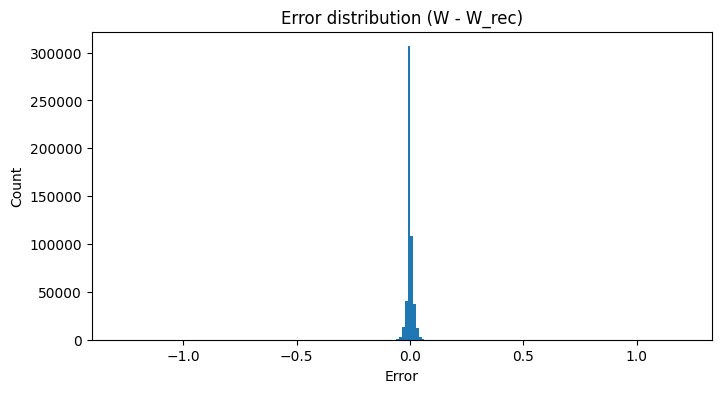

In [8]:
import matplotlib.pyplot as plt

diff = (W - W_rec).flatten()

plt.figure(figsize=(8,4))
plt.hist(diff, bins=200)
plt.title("Error distribution (W - W_rec)")
plt.xlabel("Error")
plt.ylabel("Count")
plt.show()